#### This is a sample of 1 row with headers explanation:
##### 1,PAYMENT,1060.31,C429214117,1089.0,28.69,M1591654462,0.0,0.0,0,0

**step** - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

**type** - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

**amount** -
amount of the transaction in local currency.

**nameOrig** - customer who started the transaction

**oldbalanceOrg** - initial balance before the transaction

**newbalanceOrig** - new balance after the transaction.

**nameDest** - customer who is the recipient of the transaction

**oldbalanceDest** - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

**newbalanceDest**- new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

**isFraud** - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

**isFlaggedFraud** - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import precision_score,recall_score,roc_auc_score,accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")

In [3]:
data_cleaned=pd.read_csv("cleaned_data_original_scale.csv")
data_cleaned.shape

(6079707, 7)

In [4]:
data_cleaned

,step,type,amount,net_sender,net_receiver,transactionType_CM,isFraud
0,1.0,3.0,9839.64,9839.64,1.455192e-11,1.0,0.0
1,1.0,3.0,1864.28,1864.28,1.455192e-11,1.0,0.0
2,1.0,3.0,11668.14,11668.14,1.455192e-11,1.0,0.0
3,1.0,3.0,7817.71,7817.71,1.455192e-11,1.0,0.0
4,1.0,3.0,7107.77,7107.77,1.455192e-11,1.0,0.0
...,...,...,...,...,...,...,...
6079702,743.0,1.0,339682.13,339682.13,3.396821e+05,0.0,1.0
6079703,743.0,4.0,6311409.28,6311409.28,1.455192e-11,0.0,1.0
6079704,743.0,1.0,6311409.28,6311409.28,6.311409e+06,0.0,1.0
6079705,743.0,4.0,850002.52,850002.52,1.455192e-11,0.0,1.0


## Feature Engineering based on cleaned data

In [5]:
data_cleaned['sin_step'] = np.sin(2 * np.pi * data_cleaned['step'] % 24 / 24)

In [6]:
data_cleaned['cos_step'] = np.cos(2 * np.pi * data_cleaned['step'] % 24 / 24)

In [7]:
data_dropstep=data_cleaned.drop(columns=['step'])

In [8]:
data_dropstep.head()


,type,amount,net_sender,net_receiver,transactionType_CM,isFraud,sin_step,cos_step
0,3.0,9839.64,9839.64,1.455192e-11,1.0,0.0,0.258819,0.965926
1,3.0,1864.28,1864.28,1.455192e-11,1.0,0.0,0.258819,0.965926
2,3.0,11668.14,11668.14,1.455192e-11,1.0,0.0,0.258819,0.965926
3,3.0,7817.71,7817.71,1.455192e-11,1.0,0.0,0.258819,0.965926
4,3.0,7107.77,7107.77,1.455192e-11,1.0,0.0,0.258819,0.965926


In [9]:
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
type_encoder = encoder.fit_transform(data_dropstep[['type']])

In [10]:
# Convert to DataFrame
type_encoded_df = pd.DataFrame(
    type_encoder,
    columns=encoder.get_feature_names_out(['type']),
    index=data_dropstep.index
)

# Concatenate back to the original data
data_dropstep = data_dropstep.drop(columns=['type'])
data_dropstep = pd.concat([data_dropstep, type_encoded_df], axis=1)

In [11]:
data_cleaned_encoder=data_dropstep.drop(columns=['type_2.220446049250313e-16'])
# data_cleaned_encoder=data_cleaned_encoder.drop(columns=['step'])
data_cleaned_encoder.head()

,amount,net_sender,net_receiver,transactionType_CM,isFraud,sin_step,cos_step,type_1.0,type_2.0,type_3.0,type_4.0
0,9839.64,9839.64,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
1,1864.28,1864.28,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
2,11668.14,11668.14,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
3,7817.71,7817.71,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
4,7107.77,7107.77,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0


In [12]:
data_cleaned_encoder.head()

,amount,net_sender,net_receiver,transactionType_CM,isFraud,sin_step,cos_step,type_1.0,type_2.0,type_3.0,type_4.0
0,9839.64,9839.64,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
1,1864.28,1864.28,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
2,11668.14,11668.14,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
3,7817.71,7817.71,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0
4,7107.77,7107.77,1.455192e-11,1.0,0.0,0.258819,0.965926,0.0,0.0,1.0,0.0


## Data Splitting

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Separate normal and fraud data
fraud_data = data_cleaned_encoder[data_cleaned_encoder['isFraud'] == 1]
normal_data = data_cleaned_encoder[data_cleaned_encoder['isFraud'] == 0]

# 1. Shuffle and split into 5 groups
fraud_groups = np.array_split(fraud_data.sample(frac=1, random_state=42), 5)

# 2. Choose two groups for validation, the remaining three for testing (you can change the combination below)
val_indices = [0, 1]  # Use group 0 and group 1 to form fraud_val
test_indices = [i for i in range(5) if i not in val_indices]  # [2, 3, 4]

# 3. Combine validation groups
fraud_val = pd.concat([fraud_groups[i] for i in val_indices], axis=0).reset_index(drop=True)

# 4. Keep three fraud_test groups for later testing
fraud_test_groups = [fraud_groups[i].reset_index(drop=True) for i in test_indices]

# Split normal data: 60% for training, 20% for validation, 20% for testing
normal_train, normal_temp = train_test_split(normal_data, test_size=0.4, random_state=42)
normal_val, normal_test = train_test_split(normal_temp, test_size=0.5, random_state=42)

# Balance the test set by matching its size with any one fraud test group
normal_test2 = normal_test.sample(n=len(fraud_groups[2]), random_state=42)

# ✅ Keep validation sets as two parts: fraud_val, normal_val
# 4. The test set can still be merged later if needed
# test_data = pd.concat([fraud_test, normal_test]).sample(frac=1, random_state=42).reset_index(drop=True)
train_data = normal_train.copy()

# 5. Prepare features and labels
X_train = train_data.drop(columns=['isFraud'])

# Keep validation features and labels for fraud and normal separately
X_val_fraud = fraud_val.drop(columns=['isFraud'])
y_val_fraud = fraud_val['isFraud']

X_val_normal = normal_val.drop(columns=['isFraud'])
y_val_normal = normal_val['isFraud']

# Test set features and labels (if merged later)
# X_test = test_data.drop(columns=['isFraud'])
# y_test = test_data['isFraud']


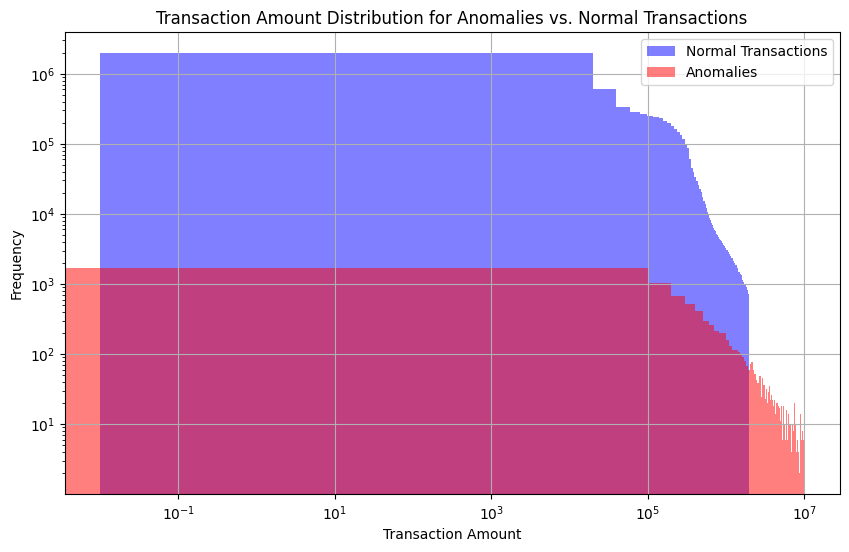

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
plt.hist(normal_data['amount'], bins=100, alpha=0.5, label='Normal Transactions', color='blue', log=True)
plt.hist(fraud_data['amount'], bins=100, alpha=0.5, label='Anomalies', color='red', log=True)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution for Anomalies vs. Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
print("✅ Unique values in train_data['isFraud']:")
print(train_data['isFraud'].value_counts())

✅ Unique values in train_data['isFraud']:
isFraud
0.0    3642896
Name: count, dtype: int64


In [15]:
X_train.head()

,amount,net_sender,net_receiver,transactionType_CM,sin_step,cos_step,type_1.0,type_2.0,type_3.0,type_4.0
5721310,2328.28,0.00,1.455192e-11,1.0,0.693944,0.720029,0.0,0.0,1.0,0.0
5484549,7761.13,-7761.13,-7.761130e+03,0.0,0.804217,0.594336,0.0,0.0,0.0,0.0
3512466,139942.51,-139942.51,-1.399425e+05,0.0,0.669126,0.743149,0.0,0.0,0.0,0.0
3970688,135513.10,12609.00,1.355131e+05,0.0,0.718481,0.695547,1.0,0.0,0.0,0.0
2074446,88899.19,-88899.19,-8.889920e+04,0.0,0.170254,0.985400,0.0,0.0,0.0,0.0


## Data Preprocessing

In [16]:
# ========== 2. Feature Preprocessing ==========
preprocessor = ColumnTransformer(
    transformers=[
        ('cont', StandardScaler(), ['amount', 'net_sender', 'net_receiver']),
        ('sin_cos', 'passthrough', ['sin_step', 'cos_step']),
        ('onehot', 'passthrough', ['transactionType_CM', 'type_1.0', 'type_2.0', 'type_3.0', 'type_4.0'])
    ]
)


    
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_fraud_scaled = preprocessor.transform(X_val_fraud)
X_val_normal_scaled = preprocessor.transform(X_val_normal)
# X_test_scaled = preprocessor.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_fraud_tensor = torch.FloatTensor(X_val_fraud_scaled)
X_val_normal_tensor = torch.FloatTensor(X_val_normal_scaled)
# X_test_tensor = torch.FloatTensor(X_test_scaled)


## Define Autoencoder Model

In [17]:
# ========== 3. Define Autoencoder Model ==========
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 6),
            nn.LeakyReLU(0.01),
            nn.Linear(6, 3)
            # nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 6),
            nn.LeakyReLU(0.01),
            nn.Linear(6, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

## Modle Training

In [18]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

input_dim = X_train_tensor.shape[1]
model = Autoencoder(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
train_mse_losses, train_mae_losses = [], []
val_mse_normal, val_mae_normal = [], []
val_mse_fraud, val_mae_fraud = [], []

best_loss = float('inf')
wait = 0
patience = 5
best_model_state = None
loss_gaps = []

for epoch in range(num_epochs):
    model.train()
    total_mse, total_mae = 0, 0
    for inputs, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        mse_loss = F.mse_loss(outputs, inputs)
        mae_loss = F.l1_loss(outputs, inputs)
        loss = mse_loss + mae_loss
        loss.backward()
        optimizer.step()
        total_mse += mse_loss.item()
        total_mae += mae_loss.item()

    train_mse_losses.append(total_mse / len(train_loader))
    train_mae_losses.append(total_mae / len(train_loader))
    # validation
    model.eval()
    with torch.no_grad():
        recon_n = model(X_val_normal_tensor)
        recon_f = model(X_val_fraud_tensor)

        val_mse_n = F.mse_loss(recon_n, X_val_normal_tensor).item()
        val_mae_n = F.l1_loss(recon_n, X_val_normal_tensor).item()
        val_mse_f = F.mse_loss(recon_f, X_val_fraud_tensor).item()
        val_mae_f = F.l1_loss(recon_f, X_val_fraud_tensor).item()

        val_mse_normal.append(val_mse_n)
        val_mae_normal.append(val_mae_n)
        val_mse_fraud.append(val_mse_f)
        val_mae_fraud.append(val_mae_f)

        gap = val_mse_f - val_mse_n
        loss_gaps.append(gap)

    print(f"Epoch {epoch+1}/{num_epochs} | Train MSE: {train_mse_losses[-1]:.4f} | MAE: {train_mae_losses[-1]:.4f}")
    print(f"  Val Normal  - MSE: {val_mse_n:.4f} | MAE: {val_mae_n:.4f}")
    print(f"  Val Fraud   - MSE: {val_mse_f:.4f} | MAE: {val_mae_f:.4f} | Gap: {gap:.4f}")

    # Early stopping check
    if val_mse_n < best_loss - 1e-6:
        best_loss = val_mse_n
        wait = 0
        best_model_state = model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

# Restore the best model
model.load_state_dict(best_model_state)
print("✅ Best model loaded.")

# # Plot the Fraud-Normal gap curve
# plt.plot(loss_gaps, marker='o', label='Fraud - Normal MSE Gap')
# plt.xlabel("Epoch")
# plt.ylabel("Loss Gap")
# plt.title("Fraud-Normal MSE Gap Over Epochs")
# plt.grid(True)
# plt.legend()
# plt.show()

Epoch 1/15 | Train MSE: 0.0258 | MAE: 0.0664
  Val Normal  - MSE: 0.0231 | MAE: 0.0635
  Val Fraud   - MSE: 45.5573 | MAE: 2.0189 | Gap: 45.5343
Epoch 2/15 | Train MSE: 0.0229 | MAE: 0.0630
  Val Normal  - MSE: 0.0221 | MAE: 0.0626
  Val Fraud   - MSE: 72.2525 | MAE: 2.2876 | Gap: 72.2304
Epoch 3/15 | Train MSE: 0.0198 | MAE: 0.0518
  Val Normal  - MSE: 0.0195 | MAE: 0.0505
  Val Fraud   - MSE: 62.3807 | MAE: 1.8819 | Gap: 62.3612
Epoch 4/15 | Train MSE: 0.0194 | MAE: 0.0504
  Val Normal  - MSE: 0.0195 | MAE: 0.0506
  Val Fraud   - MSE: 53.7117 | MAE: 1.8042 | Gap: 53.6922
Epoch 5/15 | Train MSE: 0.0193 | MAE: 0.0502
  Val Normal  - MSE: 0.0193 | MAE: 0.0503
  Val Fraud   - MSE: 51.5834 | MAE: 1.8645 | Gap: 51.5641
Epoch 6/15 | Train MSE: 0.0193 | MAE: 0.0499
  Val Normal  - MSE: 0.0194 | MAE: 0.0501
  Val Fraud   - MSE: 55.4393 | MAE: 1.9241 | Gap: 55.4198
Epoch 7/15 | Train MSE: 0.0193 | MAE: 0.0498
  Val Normal  - MSE: 0.0195 | MAE: 0.0496
  Val Fraud   - MSE: 59.9320 | MAE: 1.9432 

In [19]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=6, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=6, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=6, out_features=10, bias=True)
  )
)

In [16]:
X_train_tensor.shape[1]

10

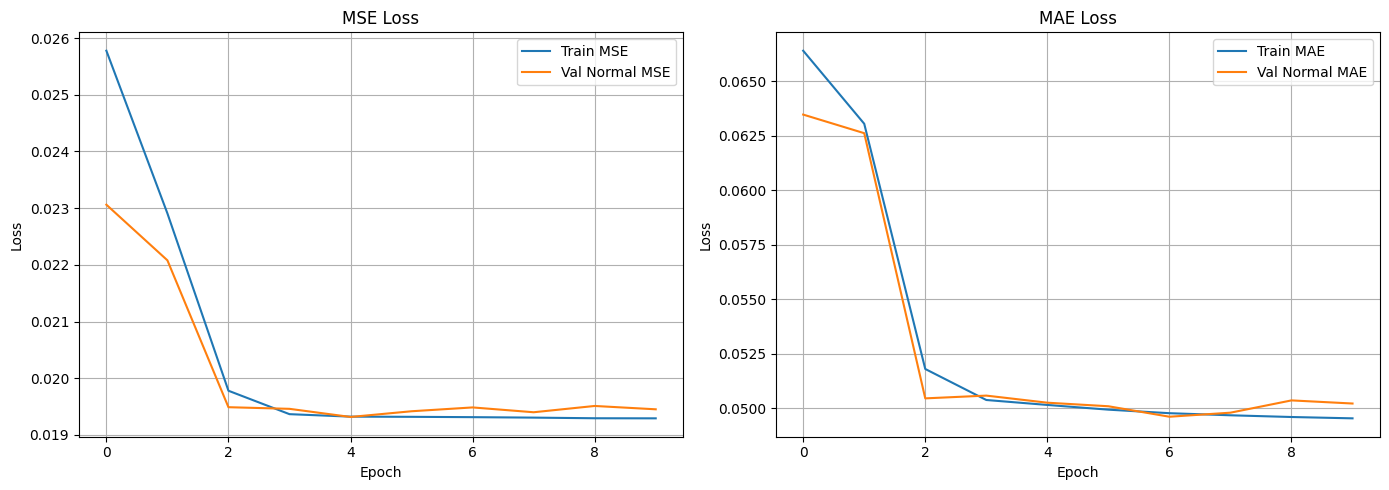

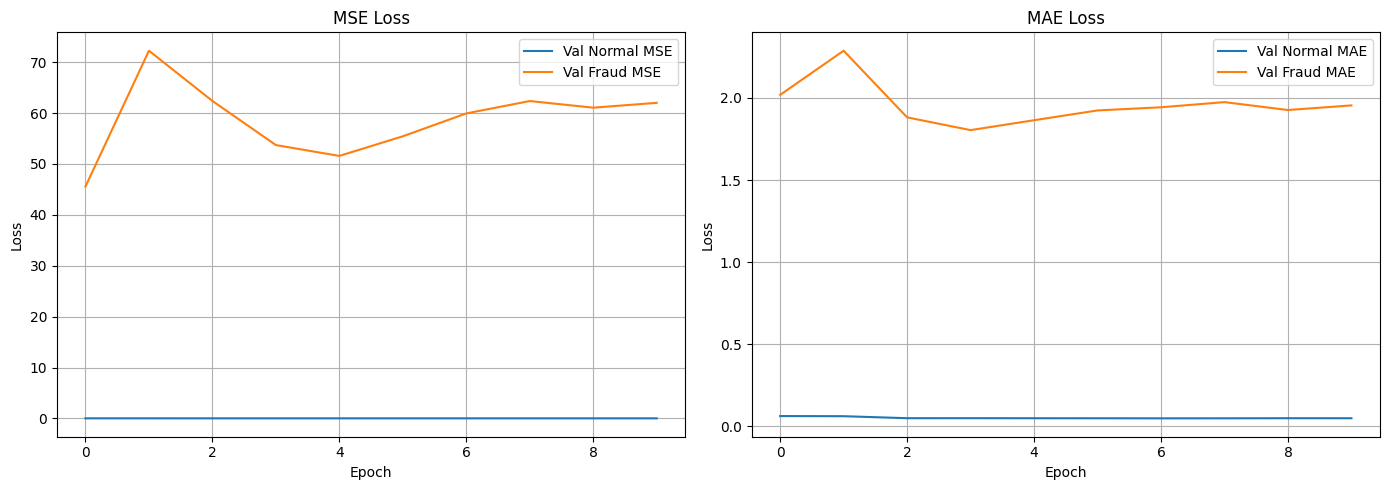

In [20]:
# ========== 5. Visualize Training Loss Curves ==========
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_mse_losses, label='Train MSE')
plt.plot(val_mse_normal, label='Val Normal MSE')
# plt.plot(val_mse_fraud, label='Val Fraud MSE')
plt.title("MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_mae_losses, label='Train MAE')
plt.plot(val_mae_normal, label='Val Normal MAE')
# plt.plot(val_mae_fraud, label='Val Fraud MAE')
plt.title("MAE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
# plt.plot(train_mse_losses, label='Train MSE')
plt.plot(val_mse_normal, label='Val Normal MSE')
plt.plot(val_mse_fraud, label='Val Fraud MSE')
plt.title("MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# plt.plot(train_mae_losses, label='Train MAE')
plt.plot(val_mae_normal, label='Val Normal MAE')
plt.plot(val_mae_fraud, label='Val Fraud MAE')
plt.title("MAE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Reconstruction error

In [21]:
with torch.no_grad():
    # Reconstruct outputs
    val_recon_normal = model(X_val_normal_tensor)
    val_recon_fraud = model(X_val_fraud_tensor)

    # MSE for each sample
    val_mse_normal = torch.mean((val_recon_normal - X_val_normal_tensor) ** 2, dim=1).numpy()
    val_mse_fraud = torch.mean((val_recon_fraud - X_val_fraud_tensor) ** 2, dim=1).numpy()

# ==== Print reconstruction error statistics for normal validation samples ====
print("✅ Reconstruction Error Stats (Normal Validation Set):")
print(f"Min      : {np.min(val_mse_normal):.6f}")
print(f"Max      : {np.max(val_mse_normal):.6f}")
print(f"Mean     : {np.mean(val_mse_normal):.6f}")
print(f"Std Dev  : {np.std(val_mse_normal):.6f}")
for q in [0.85, 0.90, 0.95, 0.99]:
    print(f"{int(q*100)}th percentile: {np.quantile(val_mse_normal, q):.6f}")

# ==== Print reconstruction error statistics for fraud validation samples ====
print("\n🚨 Reconstruction Error Stats (Fraud Validation Set):")
print(f"Min      : {np.min(val_mse_fraud):.6f}")
print(f"Max      : {np.max(val_mse_fraud):.6f}")
print(f"Mean     : {np.mean(val_mse_fraud):.6f}")
print(f"Std Dev  : {np.std(val_mse_fraud):.6f}")
for q in [0.05,0.10, 0.15,0.25, 0.50, 0.75]:
    print(f"{int(q*100)}th percentile: {np.quantile(val_mse_fraud, q):.6f}")



✅ Reconstruction Error Stats (Normal Validation Set):
Min      : 0.000020
Max      : 8.924209
Mean     : 0.019453
Std Dev  : 0.111582
85th percentile: 0.021727
90th percentile: 0.025562
95th percentile: 0.050847
99th percentile: 0.138778

🚨 Reconstruction Error Stats (Fraud Validation Set):
Min      : 0.000028
Max      : 864.738098
Mean     : 62.013409
Std Dev  : 174.646652
5th percentile: 0.002674
10th percentile: 0.006196
15th percentile: 0.012257
25th percentile: 0.059965
50th percentile: 0.260429
75th percentile: 13.471119


In [22]:

X_test_tensors = []
y_test_batches = []

for i, fraud_group in enumerate(fraud_test_groups):
    print(f"🔄  Batch {i + 1}")

    # Combine current fraud batch with normal test set
    test_data = pd.concat([fraud_group, normal_test], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

    # Features and labels
    X_test = test_data.drop(columns=['isFraud'])
    y_test = test_data['isFraud'].values

    # Preprocess & convert to tensor
    X_test_scaled = preprocessor.transform(X_test)
    X_test_tensor = torch.FloatTensor(X_test_scaled)

    # Save
    X_test_tensors.append(X_test_tensor)
    y_test_batches.append(y_test)


🔄  Batch 1
🔄  Batch 2
🔄  Batch 3


#### Normal Validation Set 95th percentile 

In [24]:
# Normal Validation Set 95th percentile 
threshold1 = 0.050847
# Batch 1
with torch.no_grad():
    recon1 = model(X_test_tensors[0])
    mse1 = torch.mean((X_test_tensors[0] - recon1) ** 2, dim=1).cpu().numpy()
y_pred1 = (mse1 > threshold1).astype(int)
print("\n📦 Batch 1 Result")
print(classification_report(y_test_batches[0], y_pred1, digits=4))

# Batch 2
with torch.no_grad():
    recon2 = model(X_test_tensors[1])
    mse2 = torch.mean((X_test_tensors[1] - recon2) ** 2, dim=1).cpu().numpy()
y_pred2 = (mse2 > threshold1).astype(int)
print("\n📦 Batch 2 Result")
print(classification_report(y_test_batches[1], y_pred2, digits=4))

# Batch 3
with torch.no_grad():
    recon3 = model(X_test_tensors[2])
    mse3 = torch.mean((X_test_tensors[2] - recon3) ** 2, dim=1).cpu().numpy()
y_pred3 = (mse3 > threshold1).astype(int)
print("\n📦 Batch 3 Result")
print(classification_report(y_test_batches[2], y_pred3, digits=4))




📦 Batch 1 Result
              precision    recall  f1-score   support

         0.0     0.9996    0.9500    0.9742   1214299
         1.0     0.0199    0.7486    0.0387      1643

    accuracy                         0.9497   1215942
   macro avg     0.5098    0.8493    0.5064   1215942
weighted avg     0.9983    0.9497    0.9729   1215942


📦 Batch 2 Result
              precision    recall  f1-score   support

         0.0     0.9997    0.9500    0.9742   1214299
         1.0     0.0203    0.7674    0.0396      1642

    accuracy                         0.9498   1215941
   macro avg     0.5100    0.8587    0.5069   1215941
weighted avg     0.9983    0.9498    0.9729   1215941


📦 Batch 3 Result
              precision    recall  f1-score   support

         0.0     0.9997    0.9500    0.9742   1214299
         1.0     0.0204    0.7716    0.0398      1642

    accuracy                         0.9498   1215941
   macro avg     0.5101    0.8608    0.5070   1215941
weighted avg     0.9

In [26]:
from sklearn.metrics import classification_report

report1 = classification_report(y_test_batches[0], y_pred1, output_dict=True)
report2 = classification_report(y_test_batches[1], y_pred2, output_dict=True)
report3 = classification_report(y_test_batches[2], y_pred3, output_dict=True)

precision_avg_fraud = np.mean([report1['1.0']['precision'], report2['1.0']['precision'], report3['1.0']['precision']])
recall_avg_fraud   = np.mean([report1['1.0']['recall'],    report2['1.0']['recall'],    report3['1.0']['recall']])
f1_avg_fraud        = np.mean([report1['1.0']['f1-score'],  report2['1.0']['f1-score'],  report3['1.0']['f1-score']])

print(f"\n Average over 3 test sets at 95th percentile (fraud class):")
print(f"Precision: {precision_avg_fraud:.4f}")
print(f"Recall:    {recall_avg_fraud:.4f}")
print(f"F1-score:  {f1_avg_fraud:.4f}")

precision_avg_normal = np.mean([report1['0.0']['precision'], report2['0.0']['precision'], report3['0.0']['precision']])
recall_avg_normal   = np.mean([report1['0.0']['recall'],    report2['0.0']['recall'],    report3['0.0']['recall']])
f1_avg_normal       = np.mean([report1['0.0']['f1-score'],  report2['0.0']['f1-score'],  report3['0.0']['f1-score']])

print(f"\n Average over 3 test sets at 95th percentile(normal):")
print(f"Precision: {precision_avg_normal:.4f}")
print(f"Recall:    {recall_avg_normal:.4f}")
print(f"F1-score:  {f1_avg_normal:.4f}")



 Average over 3 test sets at 95th percentile (fraud class):
Precision: 0.0202
Recall:    0.7625
F1-score:  0.0394

 Average over 3 test sets at 95th percentile(normal):
Precision: 0.9997
Recall:    0.9500
F1-score:  0.9742


#### Fraud Validation Set 5th percentile 

In [27]:
# Fraud Validation Set 5th percentile 
threshold2 = 0.002674
# Batch 1
with torch.no_grad():
    recon1 = model(X_test_tensors[0])
    mse1 = torch.mean((X_test_tensors[0] - recon1) ** 2, dim=1).cpu().numpy()
y_pred1 = (mse1 > threshold2).astype(int)
print("\n📦 Batch 1 Result")
print(classification_report(y_test_batches[0], y_pred1, digits=4))

# Batch 2
with torch.no_grad():
    recon2 = model(X_test_tensors[1])
    mse2 = torch.mean((X_test_tensors[1] - recon2) ** 2, dim=1).cpu().numpy()
y_pred2 = (mse2 > threshold2).astype(int)
print("\n📦 Batch 2 Result")
print(classification_report(y_test_batches[1], y_pred2, digits=4))

# Batch 3
with torch.no_grad():
    recon3 = model(X_test_tensors[2])
    mse3 = torch.mean((X_test_tensors[2] - recon3) ** 2, dim=1).cpu().numpy()
y_pred3 = (mse3 > threshold2).astype(int)
print("\n📦 Batch 3 Result")
print(classification_report(y_test_batches[2], y_pred3, digits=4))




📦 Batch 1 Result
              precision    recall  f1-score   support

         0.0     0.9997    0.2608    0.4137   1214299
         1.0     0.0017    0.9379    0.0034      1643

    accuracy                         0.2617   1215942
   macro avg     0.5007    0.5994    0.2085   1215942
weighted avg     0.9983    0.2617    0.4131   1215942


📦 Batch 2 Result
              precision    recall  f1-score   support

         0.0     0.9997    0.2608    0.4137   1214299
         1.0     0.0017    0.9470    0.0035      1642

    accuracy                         0.2617   1215941
   macro avg     0.5007    0.6039    0.2086   1215941
weighted avg     0.9984    0.2617    0.4131   1215941


📦 Batch 3 Result
              precision    recall  f1-score   support

         0.0     0.9997    0.2608    0.4137   1214299
         1.0     0.0017    0.9488    0.0035      1642

    accuracy                         0.2617   1215941
   macro avg     0.5007    0.6048    0.2086   1215941
weighted avg     0.9

In [28]:
from sklearn.metrics import classification_report

report1 = classification_report(y_test_batches[0], y_pred1, output_dict=True)
report2 = classification_report(y_test_batches[1], y_pred2, output_dict=True)
report3 = classification_report(y_test_batches[2], y_pred3, output_dict=True)

precision_avg_fraud = np.mean([report1['1.0']['precision'], report2['1.0']['precision'], report3['1.0']['precision']])
recall_avg_fraud   = np.mean([report1['1.0']['recall'],    report2['1.0']['recall'],    report3['1.0']['recall']])
f1_avg_fraud        = np.mean([report1['1.0']['f1-score'],  report2['1.0']['f1-score'],  report3['1.0']['f1-score']])

print(f"\n Average over 3 test sets at 5th percentile (fraud class):")
print(f"Precision: {precision_avg_fraud:.4f}")
print(f"Recall:    {recall_avg_fraud:.4f}")
print(f"F1-score:  {f1_avg_fraud:.4f}")

precision_avg_normal = np.mean([report1['0.0']['precision'], report2['0.0']['precision'], report3['0.0']['precision']])
recall_avg_normal   = np.mean([report1['0.0']['recall'],    report2['0.0']['recall'],    report3['0.0']['recall']])
f1_avg_normal       = np.mean([report1['0.0']['f1-score'],  report2['0.0']['f1-score'],  report3['0.0']['f1-score']])

print(f"\n Average over 3 test sets at 5th percentile(normal):")
print(f"Precision: {precision_avg_normal:.4f}")
print(f"Recall:    {recall_avg_normal:.4f}")
print(f"F1-score:  {f1_avg_normal:.4f}")



 Average over 3 test sets at 5th percentile (fraud class):
Precision: 0.0017
Recall:    0.9446
F1-score:  0.0034

 Average over 3 test sets at 5th percentile(normal):
Precision: 0.9997
Recall:    0.2608
F1-score:  0.4137


### Balanced Data

In [29]:
test_data2 = pd.concat([fraud_groups[2], normal_test2], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

In [30]:
X_test2 = test_data2.drop(columns=['isFraud'])
y_test2 = test_data2['isFraud'].values

# Preprocess & convert to tensor
X_test_scaled2 = preprocessor.transform(X_test2)
X_test_tensor2 = torch.FloatTensor(X_test_scaled2)

In [32]:
# Normal Validation Set 95th percentile 
with torch.no_grad():
    recon5 = model(X_test_tensor2)
    mse5 = torch.mean((X_test_tensor2 - recon5) ** 2, dim=1).cpu().numpy()
y_pred5 = (mse5 > threshold1).astype(int)
print("\n📦 Balanced Result at 95th percentile")
print(classification_report(y_test2, y_pred5, digits=4))


📦 Balanced Result
              precision    recall  f1-score   support

         0.0     0.7902    0.9470    0.8616      1643
         1.0     0.9339    0.7486    0.8311      1643

    accuracy                         0.8478      3286
   macro avg     0.8621    0.8478    0.8463      3286
weighted avg     0.8621    0.8478    0.8463      3286



In [34]:
# Normal Validation Set 5th percentile 
with torch.no_grad():
    recon5 = model(X_test_tensor2)
    mse5 = torch.mean((X_test_tensor2 - recon5) ** 2, dim=1).cpu().numpy()
y_pred5 = (mse5 > threshold2).astype(int)
print("\n📦 Balanced Result at 5th percentile")
print(classification_report(y_test2, y_pred5, digits=4))


📦 Balanced Result at 5th percentile
              precision    recall  f1-score   support

         0.0     0.8142    0.2721    0.4078      1643
         1.0     0.5630    0.9379    0.7037      1643

    accuracy                         0.6050      3286
   macro avg     0.6886    0.6050    0.5557      3286
weighted avg     0.6886    0.6050    0.5557      3286

